# RO simulations using `CRO` solver

This tutorial illustrates how to use the `mCRO` to solve the RO model.

This notebook was contributed by [Soong-Ki Kim](https://csd.postech.ac.kr/professor).


## RO Simulation Setup

This is the simplest configuration for the RO model, using:

- **White noise**: `n_T = 1`, `n_h = 1`.

- **Linear system**: nonlinear terms (`b_T`, `c_T`, `d_T`, `b_h`) are zero. 

- **Additive noise only**: no multiplicative component (`n_g = 2`).

The RO equation is written as:

- $\displaystyle \frac{dT}{dt} = RT + F_{1}h + \sigma_{T}w_{T}$


- $\displaystyle \frac{dh}{dt} = −\varepsilon{h} − F_{2}T + \sigma_{h}w_{h}$

The following block sets parameters for the RO simulation.

In [ ]:
R=-0.05;       % dT/dt=R*T (month^-1)
F1=0.02;       % dT/dt=F1*h (K m^-1 month^-1)
F2=0.9;        % dh/dt=-F2*T (m K^-1 month^-1)
epsilon=0.03;  % dh/dt=-epsilon*h (month^-1)

b_T=0.0;      % dT/dt=b_T*T^2 (K^-1 month^-1)
c_T=0.0;      % dT/dt=-c_T*T^3 (K^-2 month^-1)
d_T=0.0;      % dT/dt=d_T*T*h (m^-1 month^-1)
b_h=0.0;      % dh/dt=-b_h*T^2 (K^-2 m month^-1)

sigma_T=0.2;  % T-noise amplitude
sigma_h=1.2;  % h-noise amplitude
B=0.0;        % multiplicative-noise coefficient; unused for additive noise
m_T=1.0;      % red-noise damping; unused for white noise
m_h=1.0;      % red-noise damping; unused for white noise

n_T=1;        % 0: red noise, 1: white noise
n_h=1;        % 0: red noise, 1: white noise
n_g=2;        % 0: multiplicative, 1: multiplicative-H, 2: additive

par={R;F1;F2;epsilon;b_T;c_T;d_T;b_h; ...
     sigma_T;sigma_h;B;m_T;m_h;n_T;n_h;n_g};

- The following block sets additional options for the RO simulation.

In [ ]:
IC=[1.0;0.0];  % Initial conditions for T and h
N=12*100;     % Simulation length in months (100 years)
NE=2;         % Number of ensemble members

- The RO simulation can be run by setting four settings set above: par, IC, N, and NE.
- The following block sets additional **optional settings** for the RO simulation.
- The user may skip specifying these options. If the user doesn't specify these options, the RO simulation runs with the default settings.

In [ ]:
NM="EH";                    % "EH" (Euler-Heun, default) or "EM" (Euler-Maruyama)
dt=0.1;                     % Numerical time step in months (default = 0.1)
saveat=1.0;                 % Output interval in months (default = 1.0)
savemethod="sampling";      % "sampling" (default) or "mean"
EF={0.0;0.0};               % External forcing {E_T; E_h}; default is zero forcing
noise_custom=999;           % Custom noise specification / random seed

% noise_custom=[] uses internally generated noise.
% A scalar is used as a random seed for reproducible noise.
% A user-supplied matrix must have size (round(N/dt)-1) x 4.

## RO Simulations


### Basic Usage


The simplest solver call uses only par, IC, N, and NE:


In [ ]:
[T_ro,h_ro,noise]=RO_solver(par,IC,N,NE);

T_ro and h_ro have shape [time × ensemble]. The third output contains the noise time series used by the integration.


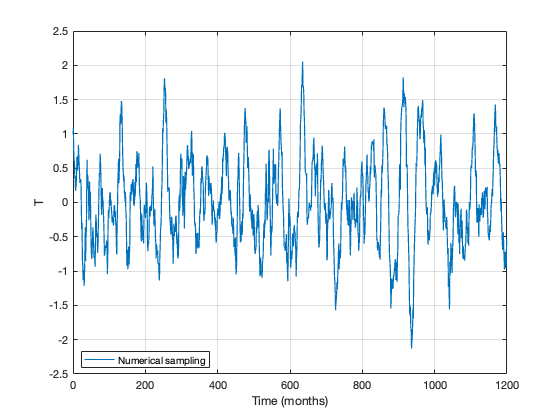

In [ ]:
% Example 3-1. Solve RO with default settings
[T_ro,h_ro,noise]=RO_solver(par,IC,N,NE);

time_axis=0:(size(T_ro,1)-1);
num_en=1; % first ensemble member

figure;
plot(time_axis,T_ro(:,num_en),'LineWidth',1.2, ...
    'DisplayName','Numerical sampling')
xlabel('Time (months)')
ylabel('T')
legend('Location','best')
grid on

### Advanced Usage


Optional arguments can be added sequentially for more control over the numerical integration:


In [ ]:
[T_ro,h_ro,noise]=RO_solver(par,IC,N,NE,NM);
[T_ro,h_ro,noise]=RO_solver(par,IC,N,NE,NM,dt);
[T_ro,h_ro,noise]=RO_solver(par,IC,N,NE,NM,dt,saveat);
[T_ro,h_ro,noise]=RO_solver(par,IC,N,NE,NM,dt,saveat,savemethod);
[T_ro,h_ro,noise]=RO_solver(par,IC,N,NE,NM,dt,saveat,savemethod,EF);
[T_ro,h_ro,noise]=RO_solver(par,IC,N,NE,NM,dt,saveat,savemethod,EF,noise_custom);

Refer to the setup section above for the meaning of each optional argument.


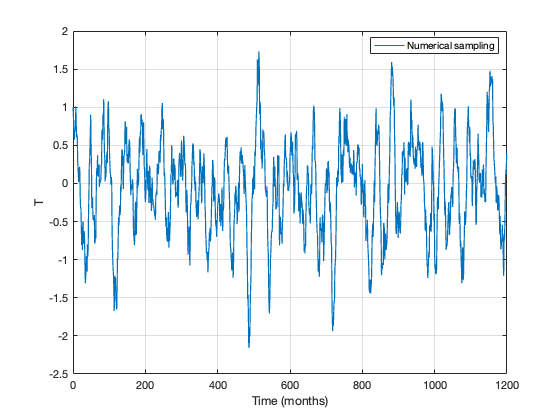

In [ ]:
% Example 3-2. Solve RO with user-specified settings
[T_ro,h_ro,noise]=RO_solver( ...
    par,IC,N,NE,NM,dt,saveat,savemethod,EF,noise_custom);

time_axis=0:saveat:(round(N/saveat)-1)*saveat;
num_en=1; % first ensemble member

figure;
plot(time_axis,T_ro(:,num_en),'LineWidth',1.2, ...
    'DisplayName','Numerical sampling')
xlabel('Time (months)')
ylabel('T')
legend('Location','best')
grid on

# 
